# Importar librerías

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import os

# Limpieza de Datos

In [2]:
df = pd.read_csv(r"C:\Users\ASUS\OneDrive - Universidad del Pacífico\High_Dimensional_Linear_Models\Python\input\apartments.csv") #Carga el archivo en un Dataframe

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110191 entries, 0 to 110190
Data columns (total 21 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    110191 non-null  object 
 1   price                 110191 non-null  int64  
 2   month                 110191 non-null  int64  
 3   area                  110191 non-null  int64  
 4   type                  86863 non-null   object 
 5   rooms                 110191 non-null  int64  
 6   centredistance        110191 non-null  float64
 7   schooldistance        110115 non-null  float64
 8   clinicdistance        109844 non-null  float64
 9   postofficedistance    110068 non-null  float64
 10  kindergartendistance  110077 non-null  float64
 11  restaurantdistance    109958 non-null  float64
 12  collegedistance       107260 non-null  float64
 13  pharmacydistance      110054 non-null  float64
 14  ownership             110191 non-null  object 
 15  

In [4]:
df.describe()

,price,month,area,rooms,centredistance,schooldistance,clinicdistance,postofficedistance,kindergartendistance,restaurantdistance,collegedistance,pharmacydistance
count,1.101910e+05,110191.000000,110191.000000,110191.000000,110191.000000,110115.000000,109844.000000,110068.000000,110077.000000,109958.000000,107260.000000,110054.000000
mean,8.231447e+05,3.697162,58.297738,2.666343,4.367885,0.409545,0.963020,0.511656,0.361129,0.337758,1.442305,0.352030
std,4.337135e+05,1.700350,21.337551,0.912880,2.808559,0.452260,0.877213,0.485859,0.429861,0.447738,1.104944,0.442009
min,1.690000e+05,1.000000,25.000000,1.000000,0.010000,0.002000,0.001000,0.001000,0.001000,0.001000,0.004000,0.001000
25%,5.500000e+05,2.000000,44.000000,2.000000,2.040000,0.177000,0.355000,0.238000,0.155000,0.111000,0.573000,0.141000
50%,7.225000e+05,4.000000,54.000000,3.000000,4.040000,0.290000,0.674000,0.394000,0.260000,0.226000,1.119000,0.238000
75%,9.700000e+05,5.000000,68.000000,3.000000,6.190000,0.467000,1.233000,0.620000,0.414000,0.406000,2.050000,0.404000
max,3.250000e+06,6.000000,150.000000,6.000000,16.740000,4.920000,4.999000,4.970000,4.961000,4.985000,5.000000,4.913000


In [53]:
df.head()

,id,price,month,area,type,rooms,centredistance,schooldistance,clinicdistance,postofficedistance,...,restaurantdistance,collegedistance,pharmacydistance,ownership,buildingmaterial,hasparkingspace,hasbalcony,haselevator,hassecurity,hasstorageroom
0,a01d82c9529f98a54d64b9e061c9a73b,1199999,1,105,apartmentBuilding,4,5.06,1.080,0.949,0.623,...,1.054,3.062,0.335,condominium,brick,no,yes,yes,no,no
1,8373aa373dbc3fe7ca3b7434166b8766,650000,1,73,tenement,3,3.24,0.275,0.672,0.367,...,0.300,1.857,0.280,condominium,brick,no,no,no,no,no
2,7d0c31d5409caab173571cce3dcdf702,590000,1,69,blockOfFlats,3,3.94,0.139,1.336,0.926,...,0.071,0.786,0.304,condominium,brick,no,yes,no,no,yes
3,3eaa36a59b9354206703b5f6b2f2ff1d,584999,1,42,blockOfFlats,2,5.19,0.209,1.533,0.201,...,0.157,2.722,0.257,condominium,NaN,no,yes,no,no,no
4,027b30cebbc49faf3094421b741ddd56,363000,1,46,blockOfFlats,2,1.65,0.250,0.624,0.510,...,0.232,0.986,0.273,condominium,concreteSlab,no,no,no,no,yes


In [5]:
df['area2'] = df['area'] ** 2

In [6]:
dummy_cols = ['hasparkingspace', 'hasbalcony', 'haselevator', 'hassecurity', 'hasstorageroom']
for col in dummy_cols:
    df[col] = (df[col] == 'yes').astype(int)

In [7]:
df.head()

,id,price,month,area,type,rooms,centredistance,schooldistance,clinicdistance,postofficedistance,...,collegedistance,pharmacydistance,ownership,buildingmaterial,hasparkingspace,hasbalcony,haselevator,hassecurity,hasstorageroom,area2
0,a01d82c9529f98a54d64b9e061c9a73b,1199999,1,105,apartmentBuilding,4,5.06,1.080,0.949,0.623,...,3.062,0.335,condominium,brick,0,1,1,0,0,11025
1,8373aa373dbc3fe7ca3b7434166b8766,650000,1,73,tenement,3,3.24,0.275,0.672,0.367,...,1.857,0.280,condominium,brick,0,0,0,0,0,5329
2,7d0c31d5409caab173571cce3dcdf702,590000,1,69,blockOfFlats,3,3.94,0.139,1.336,0.926,...,0.786,0.304,condominium,brick,0,1,0,0,1,4761
3,3eaa36a59b9354206703b5f6b2f2ff1d,584999,1,42,blockOfFlats,2,5.19,0.209,1.533,0.201,...,2.722,0.257,condominium,NaN,0,1,0,0,0,1764
4,027b30cebbc49faf3094421b741ddd56,363000,1,46,blockOfFlats,2,1.65,0.250,0.624,0.510,...,0.986,0.273,condominium,concreteSlab,0,0,0,0,1,2116


In [8]:
for i in range(10):
    df[f'end_{i}'] = (np.floor(df['area']) % 10 == i).astype(int)

In [58]:
df.head()

,id,price,month,area,type,rooms,centredistance,schooldistance,clinicdistance,postofficedistance,...,end_0,end_1,end_2,end_3,end_4,end_5,end_6,end_7,end_8,end_9
0,a01d82c9529f98a54d64b9e061c9a73b,1199999,1,105,apartmentBuilding,4,5.06,1.080,0.949,0.623,...,0,0,0,0,0,1,0,0,0,0
1,8373aa373dbc3fe7ca3b7434166b8766,650000,1,73,tenement,3,3.24,0.275,0.672,0.367,...,0,0,0,1,0,0,0,0,0,0
2,7d0c31d5409caab173571cce3dcdf702,590000,1,69,blockOfFlats,3,3.94,0.139,1.336,0.926,...,0,0,0,0,0,0,0,0,0,1
3,3eaa36a59b9354206703b5f6b2f2ff1d,584999,1,42,blockOfFlats,2,5.19,0.209,1.533,0.201,...,0,0,1,0,0,0,0,0,0,0
4,027b30cebbc49faf3094421b741ddd56,363000,1,46,blockOfFlats,2,1.65,0.250,0.624,0.510,...,0,0,0,0,0,0,1,0,0,0


In [9]:
print("Verificación de dummies por último dígito:")
for i in range(10):
    print(f"end_{i}: {df[f'end_{i}'].sum()} apartamentos")

Verificación de dummies por último dígito:
end_0: 12651 apartamentos
end_1: 8810 apartamentos
end_2: 10861 apartamentos
end_3: 10057 apartamentos
end_4: 11088 apartamentos
end_5: 10828 apartamentos
end_6: 11835 apartamentos
end_7: 11788 apartamentos
end_8: 13182 apartamentos
end_9: 9091 apartamentos


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110191 entries, 0 to 110190
Data columns (total 32 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    110191 non-null  object 
 1   price                 110191 non-null  int64  
 2   month                 110191 non-null  int64  
 3   area                  110191 non-null  int64  
 4   type                  86863 non-null   object 
 5   rooms                 110191 non-null  int64  
 6   centredistance        110191 non-null  float64
 7   schooldistance        110115 non-null  float64
 8   clinicdistance        109844 non-null  float64
 9   postofficedistance    110068 non-null  float64
 10  kindergartendistance  110077 non-null  float64
 11  restaurantdistance    109958 non-null  float64
 12  collegedistance       107260 non-null  float64
 13  pharmacydistance      110054 non-null  float64
 14  ownership             110191 non-null  object 
 15  

# LINEAR MODEL ESTIMATION

In [12]:
all_columns = df.columns.tolist()
y = df['price']
all_columns.remove('price')
all_columns.remove('id')
categorical_cols = ['month', 'type', 'rooms', 'ownership', 'buildingmaterial']
covariates = [col for col in all_columns if col not in ['end_9']]
X = pd.get_dummies(df[covariates], columns=categorical_cols, drop_first=True)

In [11]:
valores_unicos = df['type'].unique()
print(valores_unicos)

['apartmentBuilding' 'tenement' 'blockOfFlats' nan]


In [23]:
X = X.dropna()
y = y[X.index]

In [24]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [25]:
coefficients = pd.DataFrame({'Variable': X.columns, 'Coefficient': model.coef_})
coefficients.loc[len(coefficients)] = ['Intercept', model.intercept_]
print("Resumen del modelo OLS completo:")
print(coefficients)

Resumen del modelo OLS completo:
                         Variable    Coefficient
0                            area   10580.407503
1                  centredistance   21668.353634
2                  schooldistance   39708.465614
3                  clinicdistance  -55063.762832
4              postofficedistance   16024.826028
5            kindergartendistance   17467.985351
6              restaurantdistance -232602.023877
7                 collegedistance  -29927.206408
8                pharmacydistance  115649.037339
9                 hasparkingspace   12352.198755
10                     hasbalcony   16727.635334
11                    haselevator  177982.615559
12                    hassecurity   38387.498339
13                 hasstorageroom  -32609.180786
14                          area2      21.596175
15                          end_0   16150.821004
16                          end_1  -18909.056873
17                          end_2    4062.773634
18                          end_3   

In [26]:
r_squared = model.score(X, y)
print(f"R-cuadrado: {r_squared:.4f}")

R-cuadrado: 0.5737


In [27]:
end_0_coef = coefficients[coefficients['Variable'] == 'end_0']['Coefficient'].values[0] if 'end_0' in coefficients['Variable'].values else 0
print(f"\nComentario sobre end_0: El coeficiente es {end_0_coef:.2f}.")
print(f"Esto sugiere que los apartamentos con área terminando en 0 tienen un precio "
      f"{'mayor' if end_0_coef > 0 else 'menor'} en {abs(end_0_coef):.2f} unidades monetarias "
      f"comparado con aquellos que terminan en 9, ceteris paribus.")


Comentario sobre end_0: El coeficiente es 16150.82.
Esto sugiere que los apartamentos con área terminando en 0 tienen un precio mayor en 16150.82 unidades monetarias comparado con aquellos que terminan en 9, ceteris paribus.


In [28]:
X_without_end_0 = X.drop(columns=['end_0'] if 'end_0' in X.columns else [])  # Variables sin end_0

In [29]:
# Modelo para residuos de y (price)
model_y = LinearRegression()
model_y.fit(X_without_end_0, y)
e_y = y - model_y.predict(X_without_end_0)  # Residuos de price

In [30]:
# Modelo para residuos de end_0
end_0_series = X['end_0'] if 'end_0' in X.columns else pd.Series(np.zeros(len(y)))
model_d = LinearRegression()
model_d.fit(X_without_end_0, end_0_series)
e_d = end_0_series - model_d.predict(X_without_end_0)  # Residuos de end_0

In [31]:
# Modelo partialled-out
model_po = LinearRegression()
model_po.fit(e_d.values.reshape(-1, 1), e_y)

LinearRegression()

In [32]:
# Resumen del modelo partialled-out
coefficients_po = pd.DataFrame({'Variable': ['end_0'], 'Coefficient': [model_po.coef_[0]]})
coefficients_po.loc[len(coefficients_po)] = ['Intercept', model_po.intercept_]
print("\nResumen del modelo partialled-out:")
print(coefficients_po)


Resumen del modelo partialled-out:
    Variable   Coefficient
0      end_0  1.615082e+04
1  Intercept -7.822338e-11


In [33]:
# Verificar que los coeficientes son los mismos
end_0_coef_po = model_po.coef_[0]
print(f"Coeficiente de end_0 en modelo completo: {end_0_coef:.4f}")
print(f"Coeficiente de end_0 en partialling-out: {end_0_coef_po:.4f}")

Coeficiente de end_0 en modelo completo: 16150.8210
Coeficiente de end_0 en partialling-out: 16150.8210


# Price premium for area that ends in 0-digit

In [53]:
# 3c Price premium for area that ends in 0-digit (3 points)

# 1. Train the model: Estimate the same linear regression model, but only using apartments whose area does not end in 0.
# Identificar los índices de los apartamentos cuya área NO termina en 0
df_no_end_0 = df[df['end_0'] == 0].copy()

# Preparar las variables X y y para el subconjunto sin 'end_0'
# Asegurarse de que las columnas de X sean las mismas que en la parte 3b, pero sin 'end_0'
covariates_no_end_0 = [col for col in covariates if col != 'end_0']
X_no_end_0 = pd.get_dummies(df_no_end_0[covariates_no_end_0], columns=categorical_cols, drop_first=True)
y_no_end_0 = df_no_end_0['price']

# Asegurarse de que X_no_end_0 y y_no_end_0 no tengan NaNs
X_no_end_0 = X_no_end_0.dropna()
y_no_end_0 = y_no_end_0[X_no_end_0.index]

# Entrenar el modelo
model_no_end_0 = LinearRegression()
model_no_end_0.fit(X_no_end_0, y_no_end_0)

print("\n--- Parte 3c: Precio premium para áreas que terminan en 0 ---")
print("\nModelo entrenado SÓLO con apartamentos cuya área NO termina en 0.")
print("Coeficientes del modelo entrenado (excluyendo end_0):")
coefs_no_end_0 = pd.DataFrame({'Variable': X_no_end_0.columns, 'Coefficient': model_no_end_0.coef_})
coefs_no_end_0.loc[len(coefs_no_end_0)] = ['Intercept', model_no_end_0.intercept_]
print(coefs_no_end_0)



--- Parte 3c: Precio premium para áreas que terminan en 0 ---

Modelo entrenado SÓLO con apartamentos cuya área NO termina en 0.
Coeficientes del modelo entrenado (excluyendo end_0):
                         Variable    Coefficient
0                            area    9992.770237
1                  centredistance   22042.153020
2                  schooldistance   38807.770134
3                  clinicdistance  -54293.469752
4              postofficedistance   15989.968722
5            kindergartendistance   16439.121636
6              restaurantdistance -231621.101032
7                 collegedistance  -30442.044521
8                pharmacydistance  113749.505806
9                 hasparkingspace   15162.274551
10                     hasbalcony   15907.804413
11                    haselevator  174940.558870
12                    hassecurity   41026.393424
13                 hasstorageroom  -32008.706996
14                          area2      26.351177
15                          end_

In [54]:
# 2. Predict prices: Using the estimated coefficients from step 1, predict apartment prices for the entire sample,
# including those apartments whose area ends in 0.

# Para predecir sobre el conjunto completo, necesitamos crear una matriz X completa
# con las mismas columnas que se usaron para entrenar model_no_end_0.
# Esto significa que la columna 'end_0' no debe estar presente en la X completa para la predicción.
X_full_predict = pd.get_dummies(df[covariates_no_end_0], columns=categorical_cols, drop_first=True)

# Alinear las columnas de X_full_predict con las columnas de entrenamiento
# Esto es crucial para asegurar que el orden y la presencia de las columnas sean idénticos
# entre los datos de entrenamiento y los datos de predicción.
missing_cols = set(X_no_end_0.columns) - set(X_full_predict.columns)
for c in missing_cols:
    X_full_predict[c] = 0

# Asegurarse de que las columnas están en el mismo orden
X_full_predict = X_full_predict[X_no_end_0.columns]

# Manejar NaNs en X_full_predict si los hubiera antes de la predicción
# Para asegurar que la predicción se haga en un dataset limpio
X_full_predict = X_full_predict.dropna()

# Las predicciones se hacen sobre el DataFrame original, pero usando las características
# (excluyendo 'end_0') que el modelo fue entrenado.
df['predicted_price'] = np.nan # Inicializar la columna
df.loc[X_full_predict.index, 'predicted_price'] = model_no_end_0.predict(X_full_predict)

print("\nPrecios predichos para toda la muestra (incluyendo apartamentos con área terminada en 0).")
print(df[['price', 'predicted_price', 'end_0']].head())



Precios predichos para toda la muestra (incluyendo apartamentos con área terminada en 0).
     price  predicted_price  end_0
0  1199999     1.443032e+06      0
1   650000     9.003094e+05      0
2   590000     8.301712e+05      0
3   584999     4.505766e+05      0
4   363000     3.621858e+05      0


In [ ]:
# 3. Compare averages: For apartments whose area ends in 0, compute both the average actual price
# and the average predicted price. Based on this comparison, try to determine whether apartments
# with areas ending in 0 are sold at a higher price than what the model predicts.

apartments_end_0 = df[df['end_0'] == 1].copy()

average_actual_price_end_0 = apartments_end_0['price'].mean()
average_predicted_price_end_0 = apartments_end_0['predicted_price'].mean()

print(f"\nPara apartamentos cuya área termina en 0:")
print(f"  Precio real promedio: {average_actual_price_end_0:.2f} PLN")
print(f"  Precio predicho promedio: {average_predicted_price_end_0:.2f} PLN")

if average_actual_price_end_0 > average_predicted_price_end_0:
    print("\nConclusión (basada en promedios): Los apartamentos con áreas que terminan en 0")
    print("parecen venderse a un precio MAYOR de lo que el modelo predice,")
    print(f"sugiriendo un premium de aproximadamente {average_actual_price_end_0 - average_predicted_price_end_0:.2f} PLN.")
elif average_actual_price_end_0 < average_predicted_price_end_0:
    print("\nConclusión (basada en promedios): Los apartamentos con áreas que terminan en 0")
    print("parecen venderse a un precio MENOR de lo que el modelo predice,")
    print(f"sugiriendo un descuento de aproximadamente {average_predicted_price_end_0 - average_actual_price_end_0:.2f} PLN.")
else:
    print("\nConclusión (basada en promedios): Los apartamentos con áreas que terminan en 0")
    print("parecen venderse a un precio similar a lo que el modelo predice.") 


Para apartamentos cuya área termina en 0:
  Precio real promedio: 873616.30 PLN
  Precio predicho promedio: 859431.03 PLN

Conclusión (basada en promedios): Los apartamentos con áreas que terminan en 0
parecen venderse a un precio MAYOR de lo que el modelo predice,
sugiriendo un premium de aproximadamente 14185.26 PLN.


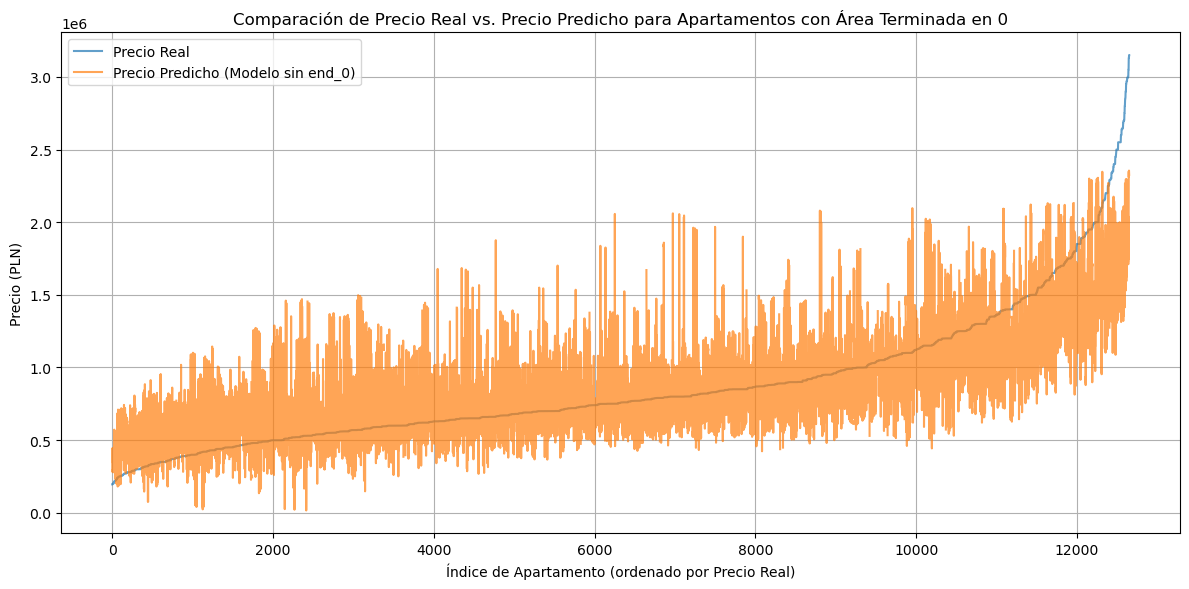

In [56]:
# Grafico de líneas comparando el precio real y el precio predicho
plt.figure(figsize=(12, 6))

# Para hacer el gráfico más legible, tomaremos una muestra aleatoria si hay muchos puntos
# O puedes ordenar por precio para ver la tendencia más clara
# Por simplicidad, tomemos todos los apartamentos cuya área termina en 0 y los ordenamos por precio real
apartments_end_0_sorted = apartments_end_0.sort_values(by='price').reset_index(drop=True)

plt.plot(apartments_end_0_sorted.index, apartments_end_0_sorted['price'], label='Precio Real', alpha=0.7)
plt.plot(apartments_end_0_sorted.index, apartments_end_0_sorted['predicted_price'], label='Precio Predicho (Modelo sin end_0)', alpha=0.7)

plt.title('Comparación de Precio Real vs. Precio Predicho para Apartamentos con Área Terminada en 0')
plt.xlabel('Índice de Apartamento (ordenado por Precio Real)')
plt.ylabel('Precio (PLN)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()